# Рынок заведений общественного питания Москвы: исследовательский анализ

Учебный проект программы «Аналитик данных» (Яндекс Практикум), выполнен самостоятельно.
Стек: Python, pandas, matplotlib, seaborn, phik.

## Цель и задачи

**Цель:** описать рынок общепита Москвы и найти характеристики, которые помогут инвестору выбрать формат, район и ценовой уровень для нового заведения.

**Что сделано:**
1. Загрузка и объединение двух таблиц, первичный осмотр.
2. Предобработка: типы данных, пропуски, нули, неявные дубликаты, новый признак `is_24_7`.
3. Исследовательский анализ: категории, округа, сетевые и несетевые заведения, посадочные места, рейтинги, связь рейтинга с другими признаками (phi_k), топ-15 сетей, средний чек по округам.
4. Итоговые выводы и рекомендации.

## Данные

Учебный датасет Яндекс Практикума о заведениях Москвы, собранный на основе Яндекс Карт и Яндекс Бизнеса (лето 2022 года). Данные являются материалами курса и в репозиторий не входят.

- **Заведения** (`rest_info.csv`, 8406 строк): название, адрес, административный округ, категория, часы работы, рейтинг, признак сетевого заведения, число посадочных мест.
- **Цены** (`rest_price.csv`, 4058 строк): ценовая категория, средний чек в виде текста и его числовая оценка, цена чашки капучино.

Таблицы связаны по `id` заведения.

## Содержание

1. Загрузка данных и первичный осмотр
2. Предобработка данных
3. Исследовательский анализ данных
4. Итоговые выводы и рекомендации

---

## 1. Загрузка данных и первичный осмотр

In [1]:
# Импортируем библиотеки
import pandas as pd

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотека для расчёта коэффициента корреляции phi_k (установка: pip install phik)
from phik import phik_matrix

In [2]:
# Загружаем данные в датафреймы rest_df и price_df
# Датасеты курса в репозиторий не входят: положите файлы в папку data/
rest_df = pd.read_csv('data/rest_info.csv')
price_df = pd.read_csv('data/rest_price.csv')

In [3]:
# Выводим первые строки датафрейма на экран
rest_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме
rest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
# Выводим первые строки датафрейма на экран
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим информацию о датафрейме
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Выводы по первичному осмотру

**Таблица заведений** (`rest_info.csv`): 8406 строк, 9 столбцов.

- Названия столбцов уже в snake_case.
- Числовые столбцы: `chain` (`int64`, значения 0 и 1, тип можно уменьшить), `rating` и `seats` (`float64`).
- Пропуски есть в `hours` и `seats`.
- Значения соответствуют описанию столбцов.

**Таблица цен** (`rest_price.csv`): 4058 строк, 5 столбцов.

- Названия столбцов уже в snake_case, типы соответствуют содержимому.
- Пропуски есть в `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup`; в `middle_coffee_cup` заполнено только 535 значений.

Цены есть не для всех заведений, поэтому таблицы объединяются левым соединением: все заведения сохраняются.

### Объединение таблиц

In [7]:
# Соединяем данные в единый датафрейм df
df = rest_df.merge(price_df, on='id', how='left')

In [8]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


Все 8406 заведений сохранились после объединения.

## 2. Предобработка данных

In [9]:
# Оптимизируем целочисленный тип данных в датафрейме df
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [10]:
# Проверим типы данных в датафрейме df с помощью атрибута dtypes
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                   int8
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

Тип `chain` уменьшен с `int64` до `int8`. Столбец `seats` переведём в целочисленный тип после заполнения пропусков.

Далее посчитаем пропуски в каждом столбце, их долю от числа строк и выберем способ обработки.

In [11]:
# Считаем количество пропусков в каждом столбце
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [12]:
# Вычисляем долю пропусков относительно общего количества строк
df.isna().sum() / df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

Пропуски: `hours` (6,4%), `seats` (43%), `price` (60,6%), `avg_bill` (54,6%), `middle_avg_bill` (62,5%), `middle_coffee_cup` (93,6%).

Решения:
- `seats`: заполнить медианой по категории, так как типичная вместимость зависит от формата заведения;
- `hours`, `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`: заменить на индикатор -1 и исключать его в расчётах; заполнение при такой доле пропусков исказило бы данные.

In [13]:
# Проверяем нули в seats, middle_avg_bill и middle_coffee_cup: такие значения не имеют смысла
print("Количество нулей:")
print("seats:", (df['seats'] == 0).sum())
print("middle_avg_bill:", (df['middle_avg_bill'] == 0).sum())
print("middle_coffee_cup:", (df['middle_coffee_cup'] == 0).sum())

Количество нулей:
seats: 136
middle_avg_bill: 1
middle_coffee_cup: 0


In [14]:
# Нули найдены в seats и middle_avg_bill: заменяем их на пропуски
for col in ['seats', 'middle_avg_bill']:
    df[col] = df[col].replace(0, pd.NA)

In [15]:
# Создаём функцию для заполнения пропусков медианой по категории для столбца seats
def fill_median_group(row):
    for col in ['seats']:
        if pd.isna(row[col]):
            group = df[
                (df['category'] == row['category'])
            ]
            row[col] = group[col].median()
    return row

In [16]:
# Применяем функцию ко всему датафрейму по строкам
df = df.apply(fill_median_group, axis=1)

In [17]:
# Заполняем оставшиеся пропуски индикатором -1 в столбцах hours, price, avg_bill, middle_avg_bill, middle_coffee_cup
for column in ['hours', 'price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup']:
    df[column] = df[column].fillna(-1)

In [18]:
# Преобразование столбца seats из float64 в int64, так как кол-во мест это целочисленные значения
df['seats'] = df['seats'].astype('int64')

In [19]:
# Проверяем типы данных после всех преобразований
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                  int64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

In [20]:
# Создаём функцию для отображения статистики пропусков
def show_missing_stats(tmp0):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

'Пропусков в данных нет'

**Выводы по обработке пропусков**

- `hours` (536 пропусков, 6,4%): индикатор -1. Вероятно, заведения не указали график в Яндекс Бизнесе.
- `seats` (3611 пропусков, 43%): 136 нулей заменены на пропуски, затем все пропуски заполнены медианой по категории.
- `price` (5091, 60,6%) и `avg_bill` (4590, 54,6%): индикатор -1. Ценовая информация есть не для всех заведений.
- `middle_avg_bill` (5257, 62,5%): один нулевой чек признан ошибкой, все пропуски заменены на -1.
- `middle_coffee_cup` (7871, 93,6%): индикатор -1. Цена капучино указывается в основном для кофеен.

Важно: построчный `apply` вернул столбцу `chain` тип `int64` (см. `dtypes` выше), `seats` приведён к `int64`. Медиана заполнила 43% значений `seats`, это нужно учитывать при анализе вместимости.

Проверим данные на явные и неявные дубликаты, начнём с полных дубликатов.

In [21]:
# Проверяем полные дубликаты в датафрейме df
df.duplicated().sum()

0

In [22]:
# Проверяем уникальные значения в поле с названием и адресом заведения
for column in ['name', 'address']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце name:
['#КешбэкКафе' '+39 Pizzeria Mozzarella bar' '1 Этаж' ... 'Ясно' 'Яуза'
 'ночной Баку']

Уникальные значения в столбце address:
['Москва, 1-й Автозаводский проезд, 5'
 'Москва, 1-й Балтийский переулок, 3/25'
 'Москва, 1-й Варшавский проезд, 1Ас9' ...
 'Москва, шоссе Энтузиастов, 86А, корп. 3' 'Москва, шоссе Энтузиастов, с2'
 'Москва, № 7']



In [23]:
# Нормализация данных в столбце name и address : нижний регистр и удаление пробелов по краям
for column in ['name', 'address']:
    df[column] = df[column].str.lower().str.strip()

In [24]:
# Число заведений с одинаковым названием, по убыванию
df.groupby('name')['id'].count().sort_values(ascending=False)

name
кафе                    189
шоколадница             120
домино'с пицца           77
додо пицца               74
one price coffee         72
                       ... 
белочка                   1
белорусская хата          1
белое озеро               1
беллини                   1
итальянский ресторан      1
Name: id, Length: 5512, dtype: int64

In [25]:
# Число заведений по одному адресу, по убыванию
df.groupby('address')['id'].count().sort_values(ascending=False)

address
москва, проспект вернадского, 86в           28
москва, усачёва улица, 26                   26
москва, ярцевская улица, 19                 20
москва, площадь киевского вокзала, 2        20
москва, щёлковское шоссе, вл75              16
                                            ..
москва, малый казённый переулок, 2           1
москва, малый ивановский переулок, 7-9с1     1
москва, малый златоустинский переулок, 2     1
москва, малый дровяной переулок, 6           1
москва, № 7                                  1
Name: id, Length: 5752, dtype: int64

In [26]:
# Функция возвращает 1 для круглосуточных заведений, иначе 0
def create_is_24_7(hours):
    if hours == 'ежедневно, круглосуточно':
        return 1
    return 0

In [27]:
# Создаём столбец is_24_7 с помощью функции create_is_24_7
df['is_24_7'] = df['hours'].apply(create_is_24_7)

In [28]:
# 20 самых частых названий
df['name'].value_counts().head(20)

кафе                                   189
шоколадница                            120
домино'с пицца                          77
додо пицца                              74
one price coffee                        72
яндекс лавка                            69
cofix                                   65
prime                                   50
хинкальная                              44
шаурма                                  43
кофепорт                                42
кулинарная лавка братьев караваевых     39
теремок                                 38
чайхана                                 37
ресторан                                34
cofefest                                32
буханка                                 32
столовая                                28
му-му                                   27
drive café                              24
Name: name, dtype: int64

In [29]:
# Уникальные категории: используем их для поиска названий-категорий в name
df['category'].unique()

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

In [30]:
# Названия-категории, которые не являются брендами
generic_names = [
    'кафе', 'ресторан', 'кофейня', 'пиццерия',
    'бар,паб', 'быстрое питание', 'булочная', 'столовая', 'бар', 'паб'
]

# Подсчёт количества для каждого названия
for name in generic_names:
    count = (df['name'] == name).sum()
    print(f"{name}: {count}")

кафе: 189
ресторан: 34
кофейня: 12
пиццерия: 3
бар,паб: 0
быстрое питание: 3
булочная: 1
столовая: 28
бар: 0
паб: 1


Полных дубликатов нет. Чтобы исключить неявные дубликаты из-за регистра и лишних пробелов, названия и адреса приведены к нижнему регистру и очищены от пробелов по краям.

После нормализации видно:
- в `name` встречаются названия-категории: «кафе» (189), «ресторан» (34), «столовая» (28) и другие. Это не бренды, поэтому при анализе сетей они исключаются (список `generic_names`);
- в `address` есть адреса с большим числом заведений, например «проспект Вернадского, 86в» (28). Вероятно, это торговые или бизнес-центры;
- создан признак `is_24_7`: 1, если график равен «ежедневно, круглосуточно», иначе 0.

---

### Выводы по предобработке

- Таблицы объединены по `id`, все 8406 заведений сохранены, строки не удалялись.
- Пропуски в `seats` заполнены медианой по категории, в остальных столбцах заменены индикатором -1.
- Нули в `seats` и `middle_avg_bill` признаны ошибками и обработаны как пропуски.
- Названия и адреса нормализованы, полных дубликатов нет.
- Названия-категории («кафе», «ресторан» и др.) выделены в отдельный список для исключения при анализе сетей.
- Добавлен признак `is_24_7`.

## 3. Исследовательский анализ данных

---

### 3.1. Категории заведений

Посчитаем число заведений в каждой категории.

In [31]:
# Выводим распределение заведений по категориям (частоты)
print('Распределение данных по значениям столбца category:')
df['category'].value_counts()

Распределение данных по значениям столбца category:


кафе               2378
ресторан           2043
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

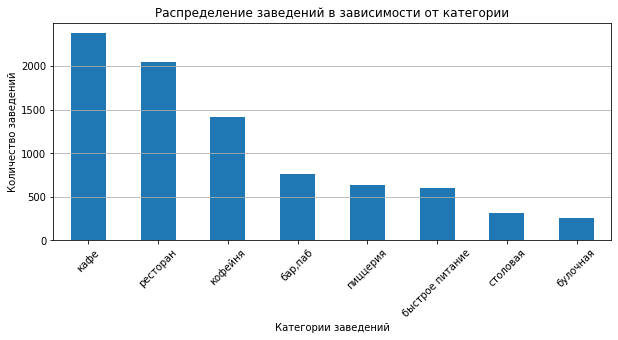

In [32]:
# Строим столбчатую диаграмму распределения по категориям
df['category'].value_counts().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=45, # Градус вращения подписи по оси Х увеличиваем на 45, чтобы категории были читаемыми
               legend=False, # Выключаем легенду
               title=f'Распределение заведений в зависимости от категории',
               figsize=(10, 4)
)

# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

Больше всего кафе (2378), ресторанов (2043) и кофеен (1413), меньше всего булочных (256). Эти три формата составляют около 69% рынка.

---

### 3.2. Заведения по административным округам

Посмотрим, как заведения распределены по округам, и отдельно разберём структуру категорий в ЦАО.

In [33]:
# Выводим распределение заведений по административным округам
print('Распределение данных по значениям столбца district:')
df['district'].value_counts()

Распределение данных по значениям столбца district:


Центральный административный округ         2242
Северный административный округ             900
Южный административный округ                892
Северо-Восточный административный округ     891
Западный административный округ             851
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

In [34]:
# Создаём словарь для сокращения названий округов (улучшает читаемость графиков)
district_short = {
    'Центральный административный округ': 'ЦАО',
    'Северный административный округ': 'САО',
    'Южный административный округ': 'ЮАО',
    'Северо-Восточный административный округ': 'СВАО',
    'Западный административный округ': 'ЗАО',
    'Восточный административный округ': 'ВАО',
    'Юго-Восточный административный округ': 'ЮВАО',
    'Юго-Западный административный округ': 'ЮЗАО',
    'Северо-Западный административный округ': 'СЗАО'
}

# Преобразуем названия округов и считаем частоты
district_counts = df['district'].map(district_short).value_counts()

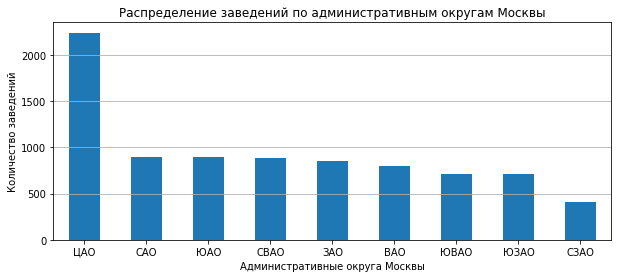

In [35]:
# Строим столбчатую диаграмму распределения по округам
district_counts.plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение заведений по административным округам Москвы',
               figsize=(10, 4)
)

# Настраиваем оформление графика
plt.xlabel('Административные округа Москвы')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

In [36]:
# Выводим распределение категорий только для ЦАО
print('Распределение данных по значениям столбца category в ЦАО:')
df.loc[df['district'] == 'Центральный административный округ']['category'].value_counts()

Распределение данных по значениям столбца category в ЦАО:


ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

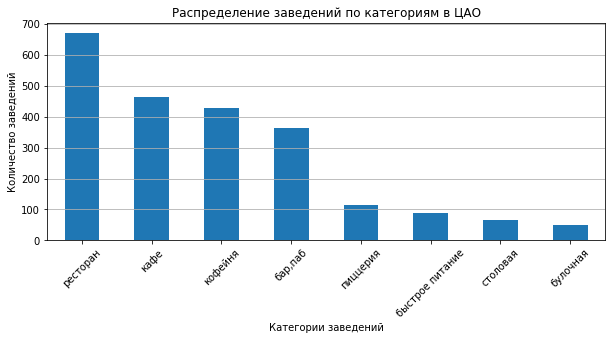

In [37]:
# Строим диаграмму категорий в ЦАО
df.loc[df['district'] == 'Центральный административный округ']['category'].value_counts().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=45, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение заведений по категориям в ЦАО',
               figsize=(10, 4)
)

# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid(axis='y')

# Выводим график
plt.show()

В ЦАО 2242 заведения (27% всех), это в 2,5 раза больше, чем в САО (900), который идёт вторым. Меньше всего заведений в СЗАО (409).

В ЦАО больше всего ресторанов (670), затем кафе (464) и кофейни (428). Если сравнить с остальными округами (разница общих данных и ЦАО), в центре ниже доля пиццерий (5,0% против 8,4%) и быстрого питания (3,9% против 8,4%), а доля ресторанов выше (29,9% против 22,3%).

---

### 3.3. Сетевые и несетевые заведения

Сравним число сетевых и несетевых заведений в целом и по категориям.

In [38]:
# Считаем количество сетевых и несетевых заведений в каждой категории
chain_by_category = df.groupby('category')['chain'].value_counts()
chain_by_category

category         chain
бар,паб          0         596
                 1         169
булочная         1         157
                 0          99
быстрое питание  0         371
                 1         232
кафе             0        1599
                 1         779
кофейня          1         720
                 0         693
пиццерия         1         330
                 0         303
ресторан         0        1313
                 1         730
столовая         0         227
                 1          88
Name: chain, dtype: int64

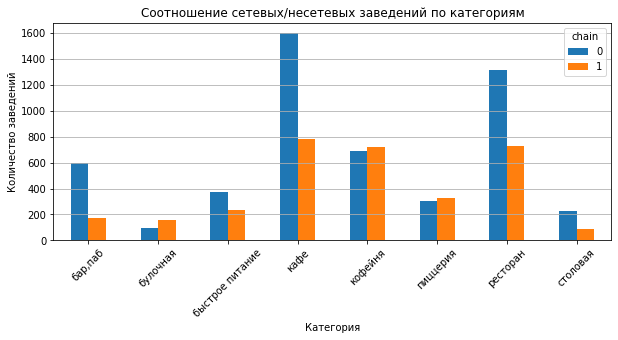

In [39]:
# Построим график столбчатой диаграммы
grouped = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
grouped.plot(kind='bar',
               title=f'Соотношение сетевых/несетевых заведений по категориям',
               legend=True,
               ylabel='Количество заведений',
               xlabel='Категория',
               rot=45,
               figsize=(10, 4))
plt.grid(axis='y')

# Выводим график
plt.show()

In [40]:
# Проверяем, каких заведений больше в целом
print(df['chain'].value_counts())

0    5201
1    3205
Name: chain, dtype: int64


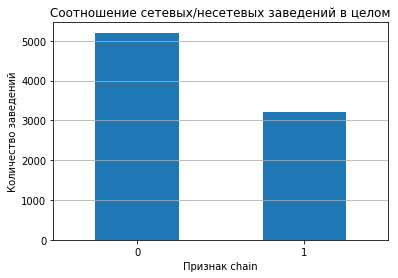

In [41]:
# Считаем общее количество сетевых/несетевых заведений
chain_counts = df['chain'].value_counts()

# Строим график
chain_counts.plot(
    kind='bar',
    title='Соотношение сетевых/несетевых заведений в целом',
    ylabel='Количество заведений',
    xlabel='Признак chain',
    rot=0,
    figsize=(6, 4)
)

plt.grid(axis='y')
plt.show()

Несетевых заведений больше: 5201 против 3205 (62% и 38%). Сетевые преобладают только в трёх категориях: булочные (61%), пиццерии (52%) и кофейни (51%). Это стандартизированные форматы, которые проще тиражировать.

---

### 3.4. Количество посадочных мест

Посмотрим на распределение посадочных мест, выбросы и типичную вместимость по категориям.

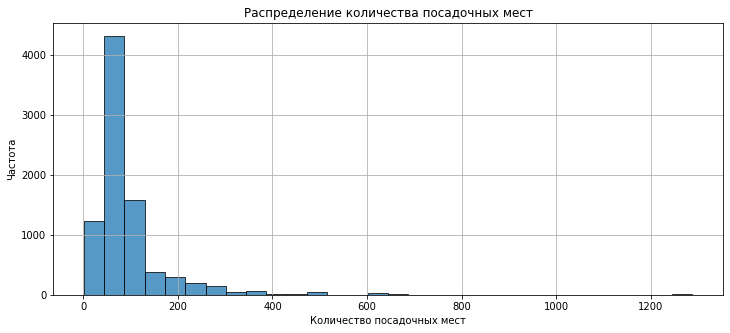

In [42]:
# Строим гистограмму с помощью pandas через plot(kind='hist')
df['seats'].plot(
                kind='hist',
                bins=30,
                alpha=0.75,
                edgecolor='black',
                rot=0,
                figsize=(12, 5)
)

# Настраиваем оформление графика
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

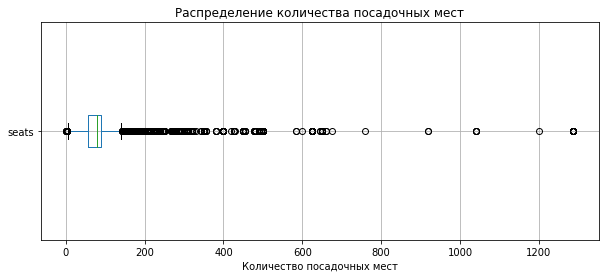

In [43]:
# Строим диаграмму размаха значений в столбце seats
df.boxplot(column='seats', vert=False, figsize=(10, 4))

# Добавляем заголовок и метки оси
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество посадочных мест')

# Выводим график
plt.show()

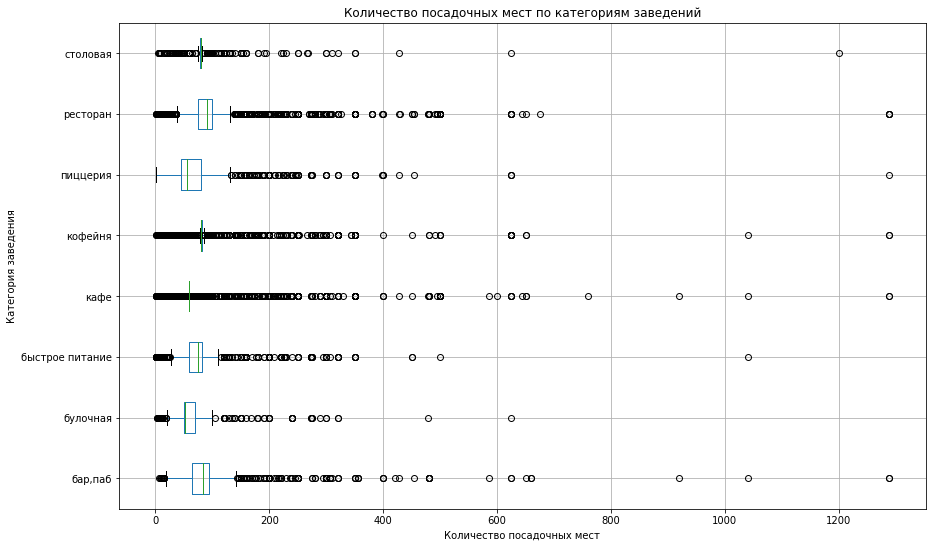

In [44]:
# Строим диаграмму размаха по категориям
df.boxplot(column='seats', by='category', vert=False, figsize=(14, 9))

# Убираем автоматический заголовок pandas
plt.suptitle('')

# Добавляем заголовок и подписи осей
plt.title('Количество посадочных мест по категориям заведений')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Категория заведения')

# Выводим график
plt.show()

In [45]:
# Для того чтобы понять распределение значений в столбце seats и выявить выбросы используем метод describe()
df['seats'].describe()

count    8406.000000
mean       94.553890
std        94.049457
min         1.000000
25%        56.000000
50%        80.000000
75%        90.000000
max      1288.000000
Name: seats, dtype: float64

In [46]:
# Для того чтобы понять распределение значений в столбце seats и выявить выбросы в разрезе категорий заведений
# также используем метод describe()
df.groupby('category')['seats'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",765.0,109.235294,114.828028,6.0,64.0,84.0,95.0,1288.0
булочная,256.0,75.847656,74.997230,3.0,50.0,52.0,70.5,625.0
быстрое питание,603.0,91.066335,80.464736,1.0,60.0,75.0,81.5,1040.0
кафе,2378.0,80.323802,85.838958,1.0,60.0,60.0,60.0,1288.0
кофейня,1413.0,97.941260,93.634075,2.0,80.0,80.0,82.0,1288.0
пиццерия,633.0,82.853081,93.420847,1.0,45.0,56.0,80.0,1288.0
ресторан,2043.0,110.738620,98.199048,2.0,75.0,90.0,100.0,1288.0
столовая,315.0,91.552381,88.404324,4.0,78.0,80.0,80.0,1200.0


Есть выбросы до 1288 мест, медиана по всем данным 80 мест. Больше всего мест у ресторанов (медиана 90) и баров (84). Меньше всего у булочных (52), пиццерий (56) и кафе (60). У кофеен и столовых медиана 80, у быстрого питания 75.

Ограничение: 43% значений заполнены медианой по категории, поэтому медианы смещены к этим значениям (например, у кафе 25-й, 50-й и 75-й перцентили равны 60).

---

### 3.5. Рейтинг по категориям

Сравним средний рейтинг категорий со средним по всем заведениям.

In [47]:
# Функция для построения столбчатой диаграммы с линией значения по всем данным
def plot_bar_plot(df, groupby, value, aggfunc, title, ylabel, xlabel):
    '''
    Функция для анализа распределения метрики по признакам:
    df - датафрейм с данными для анализа;
    groupby - str, название столбца для группировки данных;
    value - str, название столбца, значение которого будет агрегироваться;
    aggfunc - str, функция агрегации, которая используется для расчёта;
    title - str, заголовок графика;
    ylabel - str, подпись по оси Y;
    xlabel - str, подпись по оси X.
    '''
    grouped = df.groupby(groupby).agg({value:aggfunc})
    grouped.plot(kind='bar',
                   title=title,
                   legend=True,
                   ylabel=ylabel,
                   xlabel=xlabel,
                   rot=0,
                   figsize=(12, 5))

    # Рассчитываем общее значение value по всем данным
    total_value = df.agg({value:aggfunc})[0]

    # Наносим на график линию с значением value по всем данным
    plt.axhline(total_value, color='red',
                linestyle='--', linewidth=1,
                label=f'Значение по всем данным {round(total_value,4)}')

    plt.grid()
    plt.legend()
    plt.show()

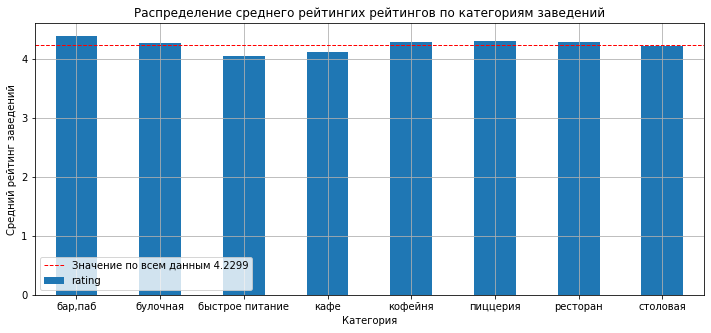

In [48]:
# Применяем функцию
plot_bar_plot(df,
              groupby='category',
              value='rating',
              aggfunc='mean',
              title='Средний рейтинг по категориям заведений',
              ylabel='Средний рейтинг заведений',
              xlabel='Категория'
              )

Средний рейтинг по всем заведениям 4,23, по категориям он лежит в узком диапазоне примерно от 4,0 до 4,4. Выше всего у баров и пабов (около 4,4), ниже всего у быстрого питания (около 4,0) и кафе. Разница между категориями небольшая.

---

### 3.6. Что связано с рейтингом

Оценим связь рейтинга с категориальными и числовыми признаками коэффициентом phi_k (только заведения с указанной ценовой категорией).

In [49]:
# Фильтруем исходный df: исключаем строки, где price == -1 (индикатор)
df_for_correlation = df[df['price'] != -1].copy()

# Вычисляем корреляционную матрицу с использованием phi_k по выбранным признакам
correlation_matrix = df_for_correlation[['category', 'district', 'chain', 'seats', 'price',
                         'is_24_7', 'rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'is_24_7', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.220295
district,0.193529
category,0.173015
chain,0.113498
is_24_7,0.094916
seats,0.000000


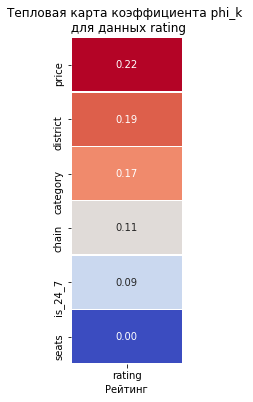

In [50]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака rating с другими признаками заведений
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

# Строим тепловую карту корреляции с рейтингом
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг')

# Выводим график
plt.show()

Сильнее всего с рейтингом связаны ценовая категория (phi_k = 0,22), округ (0,19) и категория заведения (0,17). Связь с сетевым статусом (0,11) и круглосуточной работой (0,09) слабее, с числом мест её нет (0,00). Все связи слабые, и корреляция не показывает причину.

---

### 3.7. Топ-15 сетей Москвы

Исключим названия-категории, оставим сетевые заведения и найдём 15 сетей с наибольшим числом точек, затем сравним их рейтинги.

In [51]:
# Подготавливаем данные: исключаем названия-категории, оставляем только сетевые
df_top = df[~(df['name'].isin(generic_names)) & (df['chain'] == 1)].copy()

# Считаем количество заведений по названию
top_15_networks = (df_top.groupby('name').size().reset_index(name='counts').sort_values('counts', ascending=False).head(15))

# Оставляем только эти 15 сетей
top_15_data = df_top[df_top['name'].isin(top_15_networks['name'])].copy()

# Считаем средний рейтинг и берём категорию
top_15_result = (top_15_data.groupby('name', as_index=False).agg(counts=('name', 'size'),rating=('rating', 'mean'),category=('category', 'first')).sort_values('counts', ascending=False))

# Выводим промежуточный результат отфильтрованных и отсортированных данных ТОП-15
top_15_result

,name,counts,rating,category
13,шоколадница,120,4.177500,кофейня
6,домино'с пицца,76,4.169737,пиццерия
5,додо пицца,74,4.286486,пиццерия
2,one price coffee,71,4.064789,кофейня
14,яндекс лавка,69,3.872464,ресторан
1,cofix,65,4.075385,кофейня
3,prime,50,4.116000,ресторан
11,хинкальная,44,4.322727,быстрое питание
7,кофепорт,42,4.147619,кофейня
8,кулинарная лавка братьев караваевых,39,4.394872,кафе


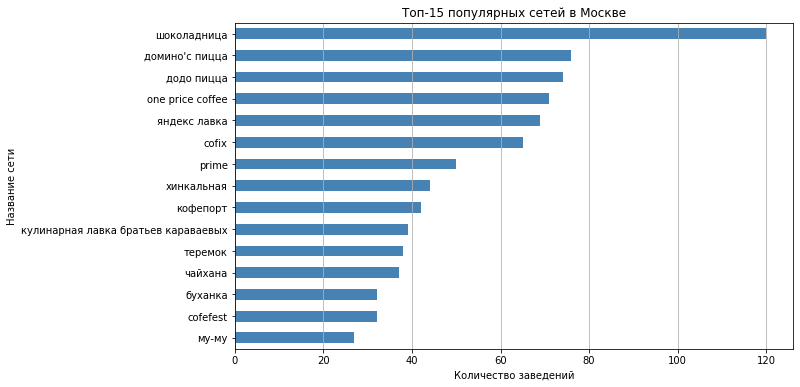

In [52]:
# Построим линейчатую диаграмму ТОП-15 заведений по их кол-ву
top_15_result.sort_values('counts').plot(
    kind='barh',
    x='name',
    y='counts',
    legend=False,
    color='steelblue',
    figsize=(10, 6)
)

plt.title('Топ-15 популярных сетей в Москве')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')
plt.grid(axis='x')
plt.show()

In [53]:
# Вариант функции для уже агрегированных данных: горизонтальная диаграмма с линией среднего
def plot_barh_with_mean(df, x_col, y_col, title, xlabel, ylabel, figsize=(10, 6)):
    '''
    Строит горизонтальную столбчатую диаграмму с линией среднего значения.
    
    Параметры:
    df — датафрейм с уже агрегированными данными (например, содержит 'name' и 'rating');
    x_col — столбец для оси X (значения, например, 'rating');
    y_col — столбец для оси Y (категории, например, 'name');
    title — заголовок графика;
    xlabel, ylabel — подписи осей.
    '''
    # Сортируем по значению для лучшей читаемости
    df_sorted = df.sort_values(by=x_col)
    
    # Строим график
    plt.figure(figsize=figsize)
    plt.barh(df_sorted[y_col], df_sorted[x_col], color='orange', edgecolor='black', alpha=0.8)
    
    # Считаем среднее по всем строкам в этом датафрейме (средний рейтинг топ-15)
    mean_value = df[x_col].mean()
    
    # Добавляем линию среднего
    plt.axvline(
        mean_value,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'Средний рейтинг (топ-15): {mean_value:.2f}'
    )
    
    # Настройка графика
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

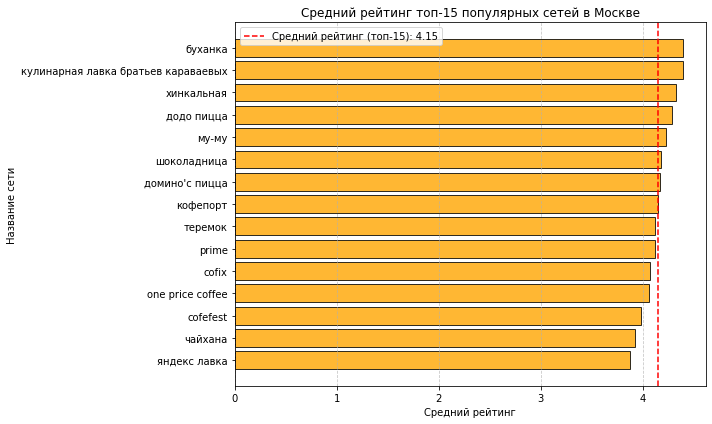

In [54]:
# Построим линейчатую диаграмму ТОП-15 сетей по рейтингу с линией среднего
plot_barh_with_mean(
    df=top_15_result,
    x_col='rating',
    y_col='name',
    title='Средний рейтинг топ-15 популярных сетей в Москве',
    xlabel='Средний рейтинг',
    ylabel='Название сети'
)

В топ-15 сетей входят 5 кофеен, по 3 ресторана и кафе, 2 пиццерии, булочная и быстрое питание (по категории первой точки сети). Больше всего точек у «Шоколадницы» (120), затем «Домино'с Пицца» (76) и «Додо Пицца» (74).

Число точек и рейтинг не совпадают:
- самые высокие рейтинги у «Буханки» (4,40) и «Кулинарной лавки братьев Караваевых» (4,39), у которых 32 и 39 точек;
- среди тройки лидеров по числу точек лучший рейтинг у «Додо Пиццы» (4,29), самый низкий в топе у «Яндекс Лавки» (3,87, 69 точек).

Ограничения: «хинкальная» и «чайхана» похожи на названия-категории, а не бренды; «Яндекс Лавка» в данных отнесена к ресторанам.

---

### 3.8. Средний чек по округам

Сравним распределение и медиану среднего чека по округам и проверим, снижается ли чек с удалением от центра.

В расчёт вошли только заведения с указанным средним чеком: 3148 из 8406.

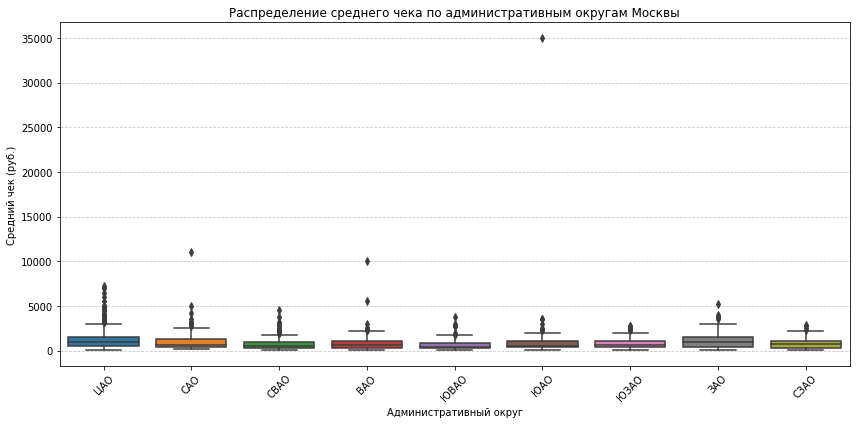

In [55]:
# Фильтруем заведения с данными о чеке (исключаем индикатор -1) и добавляем сокращённые названия округов
df_prices = df[df['middle_avg_bill'] != -1].copy()
df_prices['district_short'] = df_prices['district'].map(district_short)

# Строим boxplot по округам в порядке удаления от центра
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_prices, x='district_short', y='middle_avg_bill',
            order=['ЦАО', 'САО', 'СВАО', 'ВАО', 'ЮВАО', 'ЮАО', 'ЮЗАО', 'ЗАО', 'СЗАО'])
plt.title('Распределение среднего чека по административным округам Москвы')
plt.xlabel('Административный округ')
plt.ylabel('Средний чек (руб.)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [56]:
# Выводим медианы
median_by_district = df_prices.groupby('district_short')['middle_avg_bill'].median().sort_values(ascending=False)
print("Медианный чек по округам (от высокого к низкому):")
median_by_district

Медианный чек по округам (от высокого к низкому):


district_short
ЗАО     1000.0
ЦАО     1000.0
СЗАО     700.0
САО      650.0
ЮЗАО     600.0
ВАО      575.0
СВАО     500.0
ЮАО      500.0
ЮВАО     450.0
Name: middle_avg_bill, dtype: float64

---

- Самый высокий медианный чек в ЦАО и ЗАО: по 1000 ₽.
- Дальше идут СЗАО (700 ₽), САО (650 ₽), ЮЗАО (600 ₽) и ВАО (575 ₽).
- Самый низкий в ЮВАО (450 ₽), а также в СВАО и ЮАО (по 500 ₽).

Монотонного снижения чека от центра к окраинам нет: ЗАО не уступает ЦАО. Значит, на уровень цен влияет не только удалённость от центра; какие именно факторы, по этим данным определить нельзя.

---

### Выводы по исследовательскому анализу

- В данных 8406 заведений: 5201 несетевое и 3205 сетевых. Больше всего кафе (2378), ресторанов (2043) и кофеен (1413), меньше всего булочных (256).
- Сетевые преобладают среди булочных, пиццерий и кофеен; кафе, рестораны, бары и столовые в основном несетевые.
- В ЦАО 2242 заведения, в 2,5 раза больше, чем во втором по числу заведений САО. Медианный чек 1000 ₽ в ЦАО и ЗАО, минимальный в ЮВАО (450 ₽).
- Средний рейтинг категорий от ~4,0 (быстрое питание) до ~4,4 (бары и пабы).
- С рейтингом сильнее всего связаны ценовая категория (phi_k = 0,22) и округ (0,19), но связи слабые.
- Самая крупная сеть «Шоколадница» (120 точек); самые высокие рейтинги в топ-15 у «Буханки» (4,40) и «Кулинарной лавки братьев Караваевых» (4,39).
- Медиана посадочных мест 80; у ресторанов 90, у баров 84, у кофеен 80, у булочных, пиццерий и кафе 52–60.

## 4. Итоговые выводы и рекомендации

### Что сделано

Проанализированы данные о 8406 заведениях общепита Москвы (Яндекс Карты и Яндекс Бизнес, лето 2022 года): объединены две таблицы, обработаны пропуски, нули и неявные дубликаты, добавлен признак `is_24_7`, изучены категории, округа, сетевой статус, вместимость, рейтинги, связь рейтинга с признаками, крупнейшие сети и средний чек.

### Главные выводы

1. **Структура рынка:** кафе 28%, рестораны 24%, кофейни 17%, булочные 3%.
2. **География:** в ЦАО 27% заведений. Медианный чек 1000 ₽ в ЦАО и ЗАО, минимальный 450 ₽ в ЮВАО; чек не снижается равномерно от центра.
3. **Сети:** 62% заведений несетевые, но среди булочных, пиццерий и кофеен сетевых больше половины.
4. **Рейтинги:** от ~4,0 (быстрое питание) до ~4,4 (бары и пабы), среднее 4,23.
5. **Связь с рейтингом:** сильнее всего ценовая категория (phi_k = 0,22) и округ (0,19); связи слабые.
6. **Сети-лидеры:** больше всего точек у «Шоколадницы» (120), самые высокие рейтинги в топ-15 у «Буханки» (4,40) и «Кулинарной лавки братьев Караваевых» (4,39).
7. **Вместимость:** медиана 80 мест; рестораны 90, бары 84, булочные, пиццерии и кафе 52–60.

### Рекомендации

- **Формат.** Кофейня, пиццерия или булочная подходят для сетевого развития: в этих категориях сетевых больше половины. Бары и пабы получают самые высокие оценки, но таких заведений в 3 раза меньше, чем кафе.
- **Район.** ЦАО даёт максимальную концентрацию заведений и высокий чек, но и самую плотную конкуренцию. ЗАО сопоставим с ЦАО по медианному чеку при числе заведений в 2,6 раза меньшем (851 против 2242).
- **Цена.** Ценовая категория сильнее других признаков связана с рейтингом, поэтому её стоит выбирать вместе с концепцией и районом.
- **Вместимость.** Ориентир по медианам: около 90 мест для ресторана, 80 для кофейни, 52–60 для булочной, пиццерии или кафе.

**Ограничения:** данные на лето 2022 года, ценовая информация есть меньше чем у половины заведений, 43% значений `seats` заполнены медианой. Перед инвестиционным решением выводы стоит проверить на актуальных данных.